In [15]:
import numpy as np 
import pandas as pd

In [17]:
last = pd.read_csv("Final_Agri_Data.csv")

In [19]:
last

,N,P,K,temperature,humidity,ph,rainfall,Crop,Value
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2748.734915
1,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2271.123913
2,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2960.979166
3,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,2777.587400
4,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,3251.677623
...,...,...,...,...,...,...,...,...,...
33401,50,50,50,-5.000000,40.000000,6.000000,100.000000,jute,0.000000
33402,50,50,50,30.000000,30.000000,6.000000,0.000000,jute,0.000000
33403,0,0,0,55.000000,20.000000,6.000000,100.000000,coffee,0.000000
33404,50,50,50,-5.000000,40.000000,6.000000,100.000000,coffee,0.000000


In [21]:
last['Crop'].value_counts()


Crop
maize         2303
lentil        2303
banana        2303
watermelon    2303
muskmelon     2303
coconut       2303
cotton        2303
jute          2303
coffee        2303
rice          2257
mango         2165
chickpea      2004
pigeonpeas    2004
orange        1797
papaya        1318
mothbeans     1134
Name: count, dtype: int64

In [23]:
print("Dataset Shape:", last.shape)

Dataset Shape: (33406, 9)


In [25]:
print("Missing values before cleaning:")
print(last.isnull().sum())


Missing values before cleaning:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
Crop           0
Value          0
dtype: int64


In [27]:
print("no Duplicates ",last.duplicated().sum())

no Duplicates  0


In [29]:
last.describe()

,N,P,K,temperature,humidity,ph,rainfall,Value
count,33406.000000,33406.000000,33406.000000,33406.000000,33406.000000,33406.000000,33406.000000,33406.000000
mean,63.435910,43.630426,35.232084,25.781215,71.357271,6.493459,110.894108,9099.776839
std,38.124029,22.435916,17.285557,3.957383,20.856976,0.678167,61.172619,11527.598807
min,0.000000,0.000000,0.000000,-5.000000,14.258040,4.691396,0.000000,0.000000
25%,28.000000,24.000000,21.000000,23.584193,59.212355,6.074190,63.622508,1064.183570
50%,69.000000,43.000000,32.000000,25.787206,78.210477,6.443785,97.387415,3095.862027
75%,96.000000,60.000000,47.000000,28.113215,88.071123,6.931925,156.673255,13523.969580
max,140.000000,95.000000,85.000000,55.000000,99.981876,8.292876,295.924880,43449.929543


In [31]:
last.nunique()

N                136
P                 92
K                 63
temperature     1462
humidity        1462
ph              1460
rainfall        1461
Crop              16
Value          33359
dtype: int64

In [33]:
# 1. IMPORT TOOLS
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler


# 2. CLEAN UP
# Make a copy so we don't mess up the original data
data = last.copy()

# 3. ADD "SMART" COLUMNS
# Combine weather stats to give the AI better clues
data['weather_type'] = data['temperature'] * data['humidity']
data['dryness'] = data['rainfall'] / data['temperature']

# 4. TURN NAMES INTO NUMBERS
# Change crop names (like 'Rice') into numbers (like 0, 1, 2)
encoder = LabelEncoder()
data['crop_id'] = encoder.fit_transform(data['Crop'])

# 5. ORGANIZE DATA (X and y)
# X = The "Questions" (Soil, Weather, Crop ID)
# y = The "Answer" (The Yield Value)
X = data[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'weather_type', 'dryness', 'crop_id']]
y = data['Value']

# 6. SCALE THE NUMBERS
# Shrink all numbers to a similar range so the AI stays fair
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 7. SPLIT FOR TESTING
# Save 20% of the data to test the AI later
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("✅ Ready! Data is cleaned, scaled, and split.")

✅ Ready! Data is cleaned, scaled, and split.


In [34]:
# 1. CHOOSE THE MODEL
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

model = RandomForestRegressor(random_state=42)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy = r2_score(y_test, predictions)

error = mean_absolute_error(y_test, predictions)

print(f"Model Accuracy: {accuracy * 100:.2f}%")
print(f"Average Error: {error:.2f} Kg/Ha")

Model Accuracy: 96.23%
Average Error: 1261.63 Kg/Ha


In [35]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

print("-(Hyperparameters)... ---")


options = {
    'n_estimators': [100, 200, 300],      
    'max_depth': [10, 20, None],         
    'min_samples_split': [2, 5, 10],      
    'min_samples_leaf': [1, 2, 4]         
}

tuning_helper = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=options,
    n_iter=10,         
    cv=3,               
    verbose=1,         
    random_state=42,
    n_jobs=-1         
)


tuning_helper.fit(X_train, y_train)


print("\n Best Parameters:")
print(tuning_helper.best_params_)

best_rf_model = tuning_helper.best_estimator_

-(Hyperparameters)... ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits

 Best Parameters:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10}


--- 📊 Final Model Performance ---
Final Accuracy: 96.37%


C:\Users\nehap\AppData\Local\Temp\ipykernel_11812\391008689.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_data, palette='viridis')


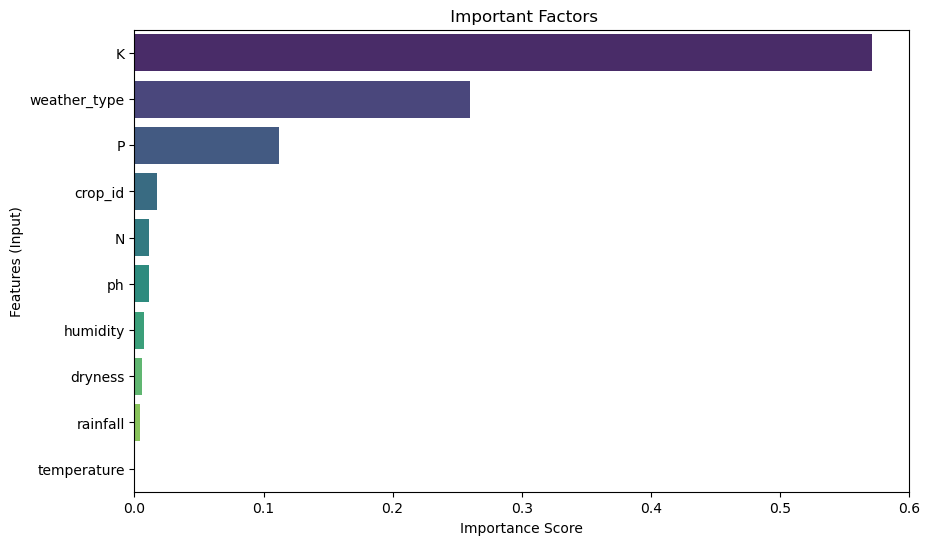


--- Files are Saving  ---
done


In [36]:
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import r2_score

# 1. BEST MODEL SELECT KARNA
# Yaad rahe: pichle code mein humne 'tuning_helper' naam use kiya tha
best_model = tuning_helper.best_estimator_

# 2. ACCURACY CHECK
print("--- 📊 Final Model Performance ---")
predictions = best_model.predict(X_test)
final_accuracy = r2_score(y_test, predictions)
print(f"Final Accuracy: {final_accuracy * 100:.2f}%")


feature_data = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_data, palette='viridis')
plt.title(' Important Factors')
plt.xlabel('Importance Score')
plt.ylabel('Features (Input)')
plt.show()


print("\n--- Files are Saving  ---")

joblib.dump(best_model, 'agri_model.pkl')      # Best Trained Model
joblib.dump(scaler, 'scaler.pkl')              # Data ko scale karne ke liye
joblib.dump(encoder, 'label_encoder.pkl')           # Crop names ko badalne ke liye
joblib.dump(list(X.columns), 'features.pkl')   # Inputs ki list

print("done")

In [37]:
import joblib
import numpy as np
import pandas as pd

def predict_yield(n, p, k, temp, hum, ph, rain, crop_name):
    try:
        # 1. Files Load karein
        model = joblib.load('agri_model.pkl')
        scaler = joblib.load('scaler.pkl')
        le = joblib.load('label_encoder.pkl')
        
        # 2. Smart Features
        weather_type = temp * hum
        dryness = rain / temp
        
        # 3. Crop ID nikalna
        try:
            crop_id = le.transform([crop_name])[0]
        except ValueError:
            print(f"⚠️ Error: '{crop_name}' in model.")
            return None

        # 4. FIX: 10 columns ka row taiyar karein (Same as training order)
        # N, P, K, temp, hum, ph, rain, weather_type, dryness, crop_id
        input_data = [[n, p, k, temp, hum, ph, rain, weather_type, dryness, crop_id]]
        
        # 5. Ab scale karein (Ab scaler ko pure 10 columns milenge)
        scaled_input = scaler.transform(input_data)
        
        # 6. Predict karein
        prediction = model.predict(scaled_input)[0]
        
        print(f"✅ Predicted Yield for {crop_name}: {prediction:.2f} Kg/Ha")
        return prediction

    except Exception as e:
        print(f" if somethng wrong: {e}")
        return None

# Test karein
predict_yield(90, 42, 43, 20.8, 82.0, 6.5, 202.9, 'jute')

✅ Predicted Yield for jute: 2511.91 Kg/Ha


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


2511.90583600922

In [9]:
joblib.dump(model, 'agri_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

print("✅ Model, Scaler aur Label Encoder successfully save ho gaye hain!")

✅ Model, Scaler aur Label Encoder successfully save ho gaye hain!
